<a href="https://colab.research.google.com/github/Michele-Bufis/Ecg-cnn-embedded/blob/main/ClassificazionePatologieECGconCNNEmbedded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificazione Patologie ECG con CNN Embedded
### GroupKFold Cross-Validation sul modello di riferimento (Tentativo 6)

5 fold raggruppati per record (paziente), non per singolo battito. Ogni fold ha training/validation diversi: garantisce che la classe Q (concentrata in pochi record) venga valutata in almeno alcuni fold, e da' una stima piu' robusta (media + deviazione standard) su tutte le classi rispetto a un singolo split fisso.

## 1. Setup ambiente

In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.5 MB/s eta 0:00:00


## 2. Download completo del dataset (48 record) + mappatura AAMI

In [ ]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }
    print(f'Record {rec_name}: {len(campioni_validi)} battiti validi')

print(f'\nTutti i {len(record_names)} record scaricati')

Record 100: 2273 battiti validi
Record 101: 1865 battiti validi
Record 102: 2187 battiti validi
Record 103: 2084 battiti validi
Record 104: 2229 battiti validi
Record 105: 2572 battiti validi
Record 106: 2027 battiti validi
Record 107: 2137 battiti validi
Record 108: 1763 battiti validi
Record 109: 2532 battiti validi
Record 111: 2124 battiti validi
Record 112: 2539 battiti validi
Record 113: 1795 battiti validi
Record 114: 1879 battiti validi
Record 115: 1953 battiti validi
Record 116: 2412 battiti validi
Record 117: 1535 battiti validi
Record 118: 2278 battiti validi
Record 119: 1987 battiti validi
Record 121: 1863 battiti validi
Record 122: 2476 battiti validi
Record 123: 1518 battiti validi
Record 124: 1619 battiti validi
Record 200: 2601 battiti validi
Record 201: 1963 battiti validi
Record 202: 2136 battiti validi
Record 203: 2980 battiti validi
Record 205: 2656 battiti validi
Record 207: 1860 battiti validi
Record 208: 2955 battiti validi
Record 209: 3005 battiti validi
Record 2

## 3. Preprocessing: filtro passa-banda

In [ ]:
from scipy.signal import butter, filtfilt

CANALE = 0

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    dataset[rec_name]['signal_filtered'] = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])

print('Filtro passa-banda applicato a tutti i record.')

## 4. Segmentazione + calcolo RR interval (su tutto il dataset, split avverra' nel k-fold)

In [ ]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200

X = []
y = []
record_id = []
rr_interval = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    diff_rr = np.diff(campioni_battiti)
    rr_mediano = np.median(diff_rr) if len(diff_rr) > 0 else 0

    for idx, (campione, classe) in enumerate(zip(campioni_battiti, classi_battiti)):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO
        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        rr = (campione - campioni_battiti[idx - 1]) if idx > 0 else rr_mediano

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        rr_interval.append(rr)

X = np.array(X).reshape(-1, FINESTRA_PRIMA + FINESTRA_DOPO, 1)
y = np.array(y)
record_id = np.array(record_id)
rr_interval = np.array(rr_interval, dtype=float)

classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(y)))}
int_to_classe = {i: c for c, i in classe_to_int.items()}
num_classi = len(classe_to_int)
y_int = np.array([classe_to_int[c] for c in y])

print(f'Segmenti totali: {len(X)}, classi: {classe_to_int}')

## 5. Salvataggio su Drive (per riuso rapido)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_full.npy', X)
np.save(f'{SALVA_DIR}/y_int_full.npy', y_int)
np.save(f'{SALVA_DIR}/record_id_full.npy', record_id)
np.save(f'{SALVA_DIR}/rr_full.npy', rr_interval)

print('Dataset completo (non splittato) salvato su Drive per uso con GroupKFold.')

## 0. Avvio rapido alternativo (se gia' salvato)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X = np.load(f'{SALVA_DIR}/X_full.npy')
y_int = np.load(f'{SALVA_DIR}/y_int_full.npy')
record_id = np.load(f'{SALVA_DIR}/record_id_full.npy')
rr_interval = np.load(f'{SALVA_DIR}/rr_full.npy')

classe_to_int = {'F': 0, 'N': 1, 'Q': 2, 'S': 3, 'V': 4}
int_to_classe = {i: c for c, i in classe_to_int.items()}
num_classi = len(classe_to_int)

print(f'Dataset completo ricaricato: {X.shape}')

Mounted at /content/drive
Dataset completo ricaricato: (109446, 300, 1)


## 6. Architettura e funzioni riutilizzabili

In [ ]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf

def costruisci_modello_duale(lunghezza_finestra, num_classi):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_classi, activation='softmax')(combinato)

    return models.Model(inputs=[input_forma, input_rr], outputs=output)

def augmenta_segmento(segmento, rng):
    aug = segmento.copy()
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)
    fattore_scala = rng.uniform(0.9, 1.1)
    return aug * fattore_scala

from sklearn.metrics import f1_score

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val_list, y_val_int):
        super().__init__()
        self.X_val_list = X_val_list
        self.y_val_int = y_val_int

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val_list, verbose=0), axis=1)
        macro_f1 = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = macro_f1

## 7. GroupKFold Cross-Validation (5 fold, raggruppati per record)

Per ogni fold: split per record, normalizzazione RR calcolata SOLO sul training del fold, augmentation su F calcolata SOLO sul training del fold (mai su validation, per non introdurre leakage tra fold), training e valutazione.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import pickle
import os

N_FOLD = 5
gkf = GroupKFold(n_splits=N_FOLD)

etichette_tutte = list(range(num_classi))
nomi_classi = [int_to_classe[i] for i in range(num_classi)]
indice_F = classe_to_int['F']

# --- Percorso file di checkpoint su Drive ---
CHECKPOINT_PATH = f'{SALVA_DIR}/groupkfold_risultati.pkl'

# --- Ripresa da sessione precedente: carica i fold gia' completati, se esistono ---
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'rb') as f:
        risultati_fold = pickle.load(f)
    fold_completati = {r['fold'] for r in risultati_fold}
    print(f'Checkpoint trovato: {len(fold_completati)} fold gia completati -> {sorted(fold_completati)}')
else:
    risultati_fold = []
    fold_completati = set()
    print('Nessun checkpoint trovato, si parte da zero.')

# --- Calcoliamo tutti gli split una volta (GroupKFold e' deterministico a parita' di input) ---
tutti_gli_split = list(gkf.split(X, y_int, groups=record_id))

for fold_num, (idx_train, idx_val) in enumerate(tutti_gli_split):
    numero_fold_umano = fold_num + 1

    if numero_fold_umano in fold_completati:
        print(f'\n===== FOLD {numero_fold_umano}/{N_FOLD} -- GIA COMPLETATO, salto =====')
        continue

    print(f'\n===== FOLD {numero_fold_umano}/{N_FOLD} =====')

    X_tr, y_tr, rr_tr = X[idx_train], y_int[idx_train], rr_interval[idx_train]
    X_va, y_va, rr_va = X[idx_val], y_int[idx_val], rr_interval[idx_val]

    rr_media = rr_tr.mean()
    rr_std = rr_tr.std()
    rr_tr_norm = (rr_tr - rr_media) / (rr_std + 1e-8)
    rr_va_norm = (rr_va - rr_media) / (rr_std + 1e-8)

    rng = np.random.default_rng(42 + fold_num)
    idx_F = np.where(y_tr == indice_F)[0]
    X_aug, rr_aug, y_aug = [], [], []
    for idx in idx_F:
        seg = X_tr[idx, :, 0]
        rr_val_orig = rr_tr_norm[idx]
        for _ in range(8):
            X_aug.append(augmenta_segmento(seg, rng))
            rr_aug.append(rr_val_orig)
            y_aug.append(indice_F)

    if len(X_aug) > 0:
        X_aug = np.array(X_aug).reshape(-1, X.shape[1], 1)
        rr_aug = np.array(rr_aug)
        y_aug = np.array(y_aug)
        X_tr_final = np.concatenate([X_tr, X_aug], axis=0)
        rr_tr_final = np.concatenate([rr_tr_norm, rr_aug], axis=0)
        y_tr_final = np.concatenate([y_tr, y_aug], axis=0)
    else:
        X_tr_final, rr_tr_final, y_tr_final = X_tr, rr_tr_norm, y_tr

    classi_presenti_train = np.unique(y_tr_final)
    pesi = compute_class_weight(class_weight='balanced', classes=classi_presenti_train, y=y_tr_final)
    class_weights = dict(zip(classi_presenti_train, pesi))

    model = costruisci_modello_duale(X.shape[1], num_classi)
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    macro_f1_cb = MacroF1Callback([X_va, rr_va_norm], y_va)
    early_stop = EarlyStopping(monitor='val_macro_f1', mode='max', patience=12, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

    # verbose=1: mostra il progresso epoca per epoca, non solo il risultato finale del fold
    model.fit(
        [X_tr_final, rr_tr_final], y_tr_final,
        validation_data=([X_va, rr_va_norm], y_va),
        epochs=40, batch_size=64, class_weight=class_weights,
        callbacks=[macro_f1_cb, early_stop, reduce_lr], verbose=1
    )

    y_pred = np.argmax(model.predict([X_va, rr_va_norm], verbose=0), axis=1)
    cm_fold = confusion_matrix(y_va, y_pred, labels=etichette_tutte)

    macro_f1 = f1_score(y_va, y_pred, labels=etichette_tutte, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_va, y_pred)
    f1_per_classe = f1_score(y_va, y_pred, labels=etichette_tutte, average=None, zero_division=0)
    classi_presenti_val = sorted(np.unique(y_va))

    print(f'\n--- Risultato Fold {numero_fold_umano} ---')
    print(f'Record nel validation: {sorted(set(record_id[idx_val]))}')
    print(f'Classi presenti nel validation: {[int_to_classe[c] for c in classi_presenti_val]}')
    print(f'Macro F1: {macro_f1:.4f} | Balanced Accuracy: {bal_acc:.4f}')
    print(classification_report(y_va, y_pred, labels=etichette_tutte, target_names=nomi_classi, zero_division=0))

    risultati_fold.append({
      'fold': numero_fold_umano,
      'macro_f1': macro_f1,
      'balanced_accuracy': bal_acc,
      'f1_per_classe': f1_per_classe,
      'classi_presenti': classi_presenti_val,
      'confusion_matrix': cm_fold   # NUOVO
    })

    # --- Salvataggio incrementale: appena finito questo fold, lo scriviamo subito su Drive ---
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(risultati_fold, f)
    print(f'>>> Fold {numero_fold_umano} salvato su Drive in {CHECKPOINT_PATH}')

print(f'\n===== Fold completati finora: {len(risultati_fold)}/{N_FOLD} =====')

Nessun checkpoint trovato, si parte da zero.

===== FOLD 1/5 =====
Epoch 1/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 110s 70ms/step - accuracy: 0.7972 - loss: 0.5095 - val_accuracy: 0.9059 - val_loss: 0.3691 - val_macro_f1: 0.5192 - learning_rate: 3.0000e-04
Epoch 2/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 93s 62ms/step - accuracy: 0.9099 - loss: 0.2153 - val_accuracy: 0.7068 - val_loss: 0.6017 - val_macro_f1: 0.4510 - learning_rate: 3.0000e-04
Epoch 3/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 91s 62ms/step - accuracy: 0.9274 - loss: 0.1757 - val_accuracy: 0.8220 - val_loss: 0.4888 - val_macro_f1: 0.4656 - learning_rate: 3.0000e-04
Epoch 4/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 89s 60ms/step - accuracy: 0.9348 - loss: 0.1597 - val_accuracy: 0.5776 - val_loss: 0.8011 - val_macro_f1: 0.4435 - learning_rate: 3.0000e-04
Epoch 5/40
1481/1481 ━━━━━━━━━━━━━━━━━━━━ 139s 58ms/step - accuracy: 0.9402 - loss: 0.1467 - val_accuracy: 0.6680 - val_loss: 0.9464 - val_macro_f1: 0.3904 - learning_rate: 3.0000e-04
Epoch 6/40
1481/

## 8. Aggregazione dei risultati tra i fold

===== RISULTATI AGGREGATI GROUPKFOLD =====
Macro F1: media=0.5174, std=0.0901
Balanced Accuracy: media=0.5530, std=0.1125

F1 medio per classe (media sui fold dove la classe era presente nel validation):
  F: media=0.0241 (presente in 5/5 fold)
  N: media=0.8930 (presente in 5/5 fold)
  Q: media=0.5516 (presente in 5/5 fold)
  S: media=0.2617 (presente in 5/5 fold)
  V: media=0.8565 (presente in 5/5 fold)


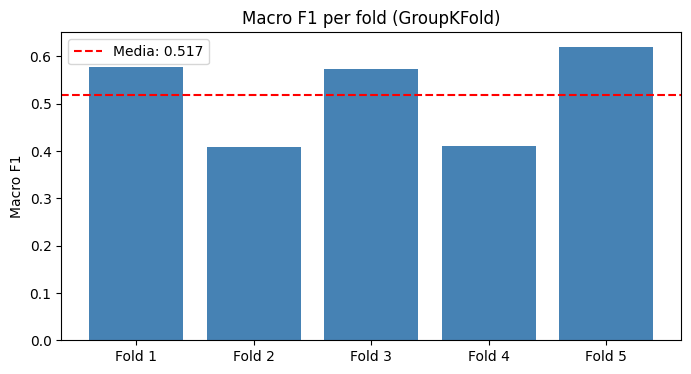

In [ ]:
macro_f1_tutti = [r['macro_f1'] for r in risultati_fold]
bal_acc_tutti = [r['balanced_accuracy'] for r in risultati_fold]

print('===== RISULTATI AGGREGATI GROUPKFOLD =====')
print(f'Macro F1: media={np.mean(macro_f1_tutti):.4f}, std={np.std(macro_f1_tutti):.4f}')
print(f'Balanced Accuracy: media={np.mean(bal_acc_tutti):.4f}, std={np.std(bal_acc_tutti):.4f}')

print('\nF1 medio per classe (media sui fold dove la classe era presente nel validation):')
f1_matrix = np.array([r['f1_per_classe'] for r in risultati_fold])
for i, nome in enumerate(nomi_classi):
    fold_con_classe = [r['f1_per_classe'][i] for r in risultati_fold if i in r['classi_presenti']]
    if fold_con_classe:
        print(f'  {nome}: media={np.mean(fold_con_classe):.4f} (presente in {len(fold_con_classe)}/{N_FOLD} fold)')
    else:
        print(f'  {nome}: MAI presente nel validation in nessun fold')

plt.figure(figsize=(8, 4))
plt.bar([f'Fold {r["fold"]}' for r in risultati_fold], macro_f1_tutti, color='steelblue')
plt.axhline(np.mean(macro_f1_tutti), color='red', linestyle='--', label=f'Media: {np.mean(macro_f1_tutti):.3f}')
plt.title('Macro F1 per fold (GroupKFold)')
plt.ylabel('Macro F1')
plt.legend()
plt.show()

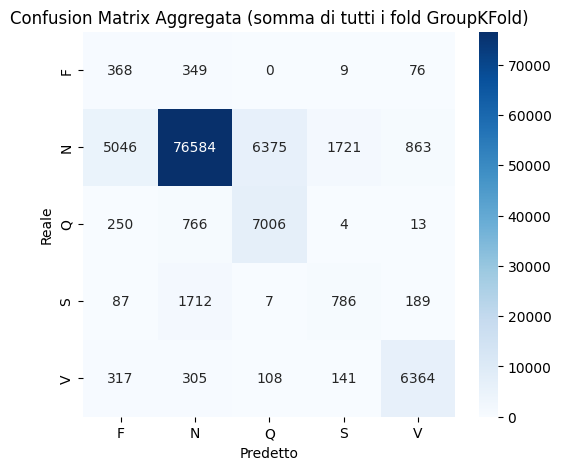

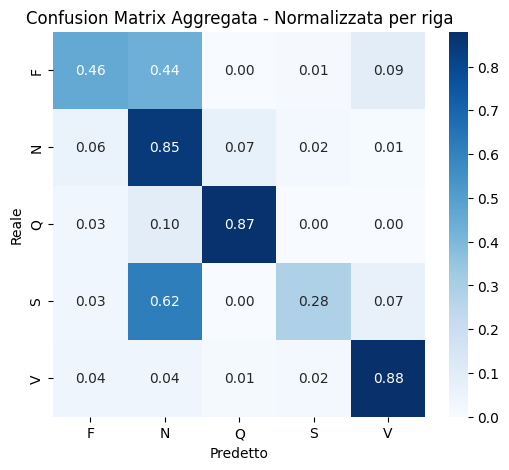

In [ ]:
import seaborn as sns

# Somma delle confusion matrix di tutti i fold: vista aggregata su tutto il dataset
cm_totale = np.sum([r['confusion_matrix'] for r in risultati_fold], axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_totale, annot=True, fmt='d', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.title('Confusion Matrix Aggregata (somma di tutti i fold GroupKFold)')
plt.show()

# Normalizzata per riga: percentuale di ogni classe reale finita in ciascuna predizione
cm_normalizzata = cm_totale.astype(float) / cm_totale.sum(axis=1, keepdims=True)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalizzata, annot=True, fmt='.2f', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale')
plt.title('Confusion Matrix Aggregata - Normalizzata per riga')
plt.show()

# Classificazione Patologie ECG con CNN Embedded
### Modello finale + soglia di confidenza + valutazione sul Test Set

Ultima fase di modellazione: training del modello definitivo su tutto il dataset disponibile per training (train+validation uniti), scelta della soglia di confidenza per la gestione della classe F (reject option), e valutazione conclusiva -- una tantum -- sul test set mai utilizzato finora.

## 0. Caricamento dati (dataset completo non splittato, gia' salvato)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X = np.load(f'{SALVA_DIR}/X_full.npy')
y_int = np.load(f'{SALVA_DIR}/y_int_full.npy')
record_id = np.load(f'{SALVA_DIR}/record_id_full.npy')
rr_interval = np.load(f'{SALVA_DIR}/rr_full.npy')

classe_to_int = {'F': 0, 'N': 1, 'Q': 2, 'S': 3, 'V': 4}
int_to_classe = {i: c for c, i in classe_to_int.items()}
num_classi = len(classe_to_int)

print(f'Dataset completo: {X.shape}')

Mounted at /content/drive
Dataset completo: (109446, 300, 1)


## 1. Split finale: Train+Validation (per allenare) vs Test (intoccato fino ad ora)

Stesso identico split di record usato fin dall'inizio del progetto (random_state=42): il test set e' esattamente quello mai osservato in nessuno dei tentativi precedenti.

In [ ]:
from sklearn.model_selection import train_test_split

record_names = sorted(set(record_id.tolist()))
record_unici = np.array(record_names)

record_train, record_valtest = train_test_split(record_unici, test_size=0.30, random_state=42)
record_val, record_test = train_test_split(record_valtest, test_size=0.50, random_state=42)

# Per il modello finale: training = train + validation originali, test resta separato
record_trainfinal = np.concatenate([record_train, record_val])

mask_trainfinal = np.isin(record_id, record_trainfinal)
mask_test = np.isin(record_id, record_test)

X_trainfinal, y_trainfinal, rr_trainfinal = X[mask_trainfinal], y_int[mask_trainfinal], rr_interval[mask_trainfinal]
X_test, y_test, rr_test = X[mask_test], y_int[mask_test], rr_interval[mask_test]

print(f'Training finale (train+val uniti): {len(y_trainfinal)} segmenti, {len(record_trainfinal)} record')
print(f'Test (MAI utilizzato finora):       {len(y_test)} segmenti, {len(record_test)} record')
print(f'Record di test: {sorted(record_test)}')

Training finale (train+val uniti): 90306 segmenti, 40 record
Test (MAI utilizzato finora):       19140 segmenti, 8 record
Record di test: [np.str_('103'), np.str_('104'), np.str_('202'), np.str_('203'), np.str_('205'), np.str_('219'), np.str_('221'), np.str_('222')]


## 2. Sotto-split interno per Early Stopping

Il training finale usa quasi tutti i dati disponibili, ma serve comunque un piccolo validation interno per decidere quando fermarsi (Early Stopping) senza toccare il test.

In [ ]:
record_train_int, record_val_int = train_test_split(record_trainfinal, test_size=0.15, random_state=42)

mask_tr = np.isin(record_id[mask_trainfinal], record_train_int)
mask_va = np.isin(record_id[mask_trainfinal], record_val_int)

X_tr, y_tr, rr_tr = X_trainfinal[mask_tr], y_trainfinal[mask_tr], rr_trainfinal[mask_tr]
X_va, y_va, rr_va = X_trainfinal[mask_va], y_trainfinal[mask_va], rr_trainfinal[mask_va]

print(f'Training interno: {len(y_tr)} segmenti')
print(f'Validation interno (solo per Early Stopping): {len(y_va)} segmenti')

Training interno: 76808 segmenti
Validation interno (solo per Early Stopping): 13498 segmenti


## 3. Normalizzazione RR, reshape, augmentation su F

In [ ]:
rr_media = rr_tr.mean()
rr_std = rr_tr.std()
rr_tr_norm = (rr_tr - rr_media) / (rr_std + 1e-8)
rr_va_norm = (rr_va - rr_media) / (rr_std + 1e-8)
rr_test_norm = (rr_test - rr_media) / (rr_std + 1e-8)

def augmenta_segmento(segmento, rng):
    aug = segmento.copy()
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)
    return aug * rng.uniform(0.9, 1.1)

rng = np.random.default_rng(42)
indice_F = classe_to_int['F']
idx_F = np.where(y_tr == indice_F)[0]

X_aug, rr_aug, y_aug = [], [], []
for idx in idx_F:
    seg = X_tr[idx, :, 0]
    rr_o = rr_tr_norm[idx]
    for _ in range(8):
        X_aug.append(augmenta_segmento(seg, rng))
        rr_aug.append(rr_o)
        y_aug.append(indice_F)

X_aug = np.array(X_aug).reshape(-1, X.shape[1], 1)
rr_aug = np.array(rr_aug)
y_aug = np.array(y_aug)

X_tr_final = np.concatenate([X_tr, X_aug], axis=0)
rr_tr_final = np.concatenate([rr_tr_norm, rr_aug], axis=0)
y_tr_final = np.concatenate([y_tr, y_aug], axis=0)

print(f'Training dopo augmentation: {len(y_tr_final)} esempi (F: {(y_tr_final==indice_F).sum()})')

Training dopo augmentation: 83096 esempi (F: 7074)


## 4. Architettura e training del modello finale

In [ ]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf
from sklearn.metrics import f1_score

def costruisci_modello_duale(lunghezza_finestra, num_classi):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_classi, activation='softmax')(combinato)
    return models.Model(inputs=[input_forma, input_rr], outputs=output)

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val_list, y_val_int):
        super().__init__()
        self.X_val_list = X_val_list
        self.y_val_int = y_val_int
    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val_list, verbose=0), axis=1)
        logs['val_macro_f1'] = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)

model_finale = costruisci_modello_duale(X.shape[1], num_classi)
model_finale.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ forma_donda         │ (None, 300, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 16)   │        160 │ forma_donda[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 16)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 150, 32)   │      3,616 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 150, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 75, 32)    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 75, 64)    │     10,304 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_interval         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 75, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rr_interval[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        365 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,061 (58.83 KB)

 Trainable params: 14,837 (57.96 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

pesi = compute_class_weight(class_weight='balanced', classes=np.unique(y_tr_final), y=y_tr_final)
class_weights = dict(zip(np.unique(y_tr_final), pesi))

model_finale.compile(optimizer=Adam(learning_rate=0.0003), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

macro_f1_cb = MacroF1Callback([X_va, rr_va_norm], y_va)
early_stop = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model_finale.fit(
    [X_tr_final, rr_tr_final], y_tr_final,
    validation_data=([X_va, rr_va_norm], y_va),
    epochs=60, batch_size=64, class_weight=class_weights,
    callbacks=[macro_f1_cb, early_stop, reduce_lr], verbose=1
)

Epoch 1/60
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.8127 - loss: 0.4627 - val_accuracy: 0.7899 - val_loss: 0.5910 - val_macro_f1: 0.4154 - learning_rate: 3.0000e-04
Epoch 2/60
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 68s 52ms/step - accuracy: 0.9401 - loss: 0.1863 - val_accuracy: 0.7832 - val_loss: 0.8123 - val_macro_f1: 0.5061 - learning_rate: 3.0000e-04
Epoch 3/60
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 63s 49ms/step - accuracy: 0.9543 - loss: 0.1492 - val_accuracy: 0.7458 - val_loss: 1.0609 - val_macro_f1: 0.4284 - learning_rate: 3.0000e-04
Epoch 4/60
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9592 - loss: 0.1323 - val_accuracy: 0.8961 - val_loss: 0.2964 - val_macro_f1: 0.4970 - learning_rate: 3.0000e-04
Epoch 5/60
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - accuracy: 0.9613 - loss: 0.1212 - val_accuracy: 0.7846 - val_loss: 0.9054 - val_macro_f1: 0.3980 - learning_rate: 3.0000e-04
Epoch 6/60
1299/1299 ━━━━━━━━━━━━━━━━━━━━ 87s 52ms/step - accuracy: 0.9640 - loss: 0.

## 5. Salvataggio del modello finale su Drive

In [ ]:
model_finale.save(f'{SALVA_DIR}/modello_finale.keras')
print('Modello finale salvato su Drive.')

Modello finale salvato su Drive.


## 6. Funzioni per la soglia di confidenza (reject option)

In [ ]:
def predici_con_soglia(model, X_input_list, soglia_confidenza, int_to_classe):
    probabilita = model.predict(X_input_list, verbose=0)
    classe_predetta = np.argmax(probabilita, axis=1)
    confidenza_massima = np.max(probabilita, axis=1)

    predizioni_finali = []
    for classe, conf in zip(classe_predetta, confidenza_massima):
        if conf >= soglia_confidenza:
            predizioni_finali.append(int_to_classe[classe])
        else:
            predizioni_finali.append('INCERTO')

    return np.array(predizioni_finali), confidenza_massima, classe_predetta

## 7. Scelta della soglia sul Validation interno (MAI sul test)

In [ ]:
import pandas as pd

soglie_da_testare = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
risultati_soglia = []

probabilita_val = model_finale.predict([X_va, rr_va_norm], verbose=0)
classe_predetta_val = np.argmax(probabilita_val, axis=1)
confidenza_val = np.max(probabilita_val, axis=1)

for soglia in soglie_da_testare:
    mask_confidenti = confidenza_val >= soglia
    coverage = mask_confidenti.mean()

    if mask_confidenti.sum() > 0:
        macro_f1_confidenti = f1_score(
            y_va[mask_confidenti], classe_predetta_val[mask_confidenti],
            labels=list(range(num_classi)), average='macro', zero_division=0
        )
    else:
        macro_f1_confidenti = np.nan

    mask_F_reali = y_va == classe_to_int['F']
    F_scartati = (mask_F_reali & ~mask_confidenti).sum()
    F_totali = mask_F_reali.sum()

    risultati_soglia.append({
        'soglia': soglia,
        'coverage': round(coverage, 3),
        'macro_f1_sui_confidenti': round(macro_f1_confidenti, 4) if not np.isnan(macro_f1_confidenti) else None,
        'F_segnalati_incerti': f'{F_scartati}/{F_totali}'
    })

df_soglie = pd.DataFrame(risultati_soglia)
print(df_soglie.to_string(index=False))

 soglia  coverage  macro_f1_sui_confidenti F_segnalati_incerti
    0.3     1.000                   0.5234                 0/2
    0.4     0.999                   0.5246                 0/2
    0.5     0.994                   0.5270                 0/2
    0.6     0.978                   0.5406                 0/2
    0.7     0.948                   0.5410                 1/2
    0.8     0.877                   0.5552                 1/2
    0.9     0.615                   0.4709                 2/2


## 8. Valutazione finale sul Test Set (una tantum)

Imposta manualmente SOGLIA_SCELTA in base ai risultati della Sezione 7, poi esegui. Questo e' l'UNICO utilizzo del test set in tutto il progetto.

Soglia usata: 0.6
Coverage sul test: 87.6% dei casi classificati, 12.4% segnalati INCERTO


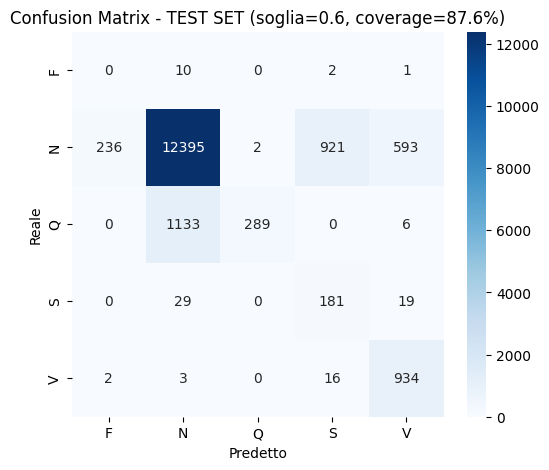

              precision    recall  f1-score   support

           F       0.00      0.00      0.00        13
           N       0.91      0.88      0.89     14147
           Q       0.99      0.20      0.34      1428
           S       0.16      0.79      0.27       229
           V       0.60      0.98      0.74       955

    accuracy                           0.82     16772
   macro avg       0.53      0.57      0.45     16772
weighted avg       0.89      0.82      0.83     16772


RISULTATO FINALE DEL PROGETTO -- Macro F1 sul test set (soglia 0.6): 0.4488


In [ ]:
SOGLIA_SCELTA = 0.6  # AGGIORNA in base alla Sezione 7 prima di eseguire

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pred_test_soglia, conf_test, pred_test_grezza = predici_con_soglia(
    model_finale, [X_test, rr_test_norm], SOGLIA_SCELTA, int_to_classe
)

coverage_test = (pred_test_soglia != 'INCERTO').mean()
print(f'Soglia usata: {SOGLIA_SCELTA}')
print(f'Coverage sul test: {coverage_test:.1%} dei casi classificati, {1-coverage_test:.1%} segnalati INCERTO')

# Valutazione sui soli casi confidenti (esclude 'INCERTO')
mask_confidenti_test = pred_test_soglia != 'INCERTO'
y_test_confidenti = y_test[mask_confidenti_test]
pred_test_confidenti_int = pred_test_grezza[mask_confidenti_test]

nomi_classi = [int_to_classe[i] for i in range(num_classi)]
cm_test = confusion_matrix(y_test_confidenti, pred_test_confidenti_int, labels=list(range(num_classi)))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title(f'Confusion Matrix - TEST SET (soglia={SOGLIA_SCELTA}, coverage={coverage_test:.1%})')
plt.show()

print(classification_report(y_test_confidenti, pred_test_confidenti_int, labels=list(range(num_classi)), target_names=nomi_classi, zero_division=0))

print(f"\nRISULTATO FINALE DEL PROGETTO -- Macro F1 sul test set (soglia {SOGLIA_SCELTA}): "
      f"{f1_score(y_test_confidenti, pred_test_confidenti_int, labels=list(range(num_classi)), average='macro', zero_division=0):.4f}")